In [1]:
import src 
import numpy as np 

%load_ext autoreload
%autoreload 2


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [ ]:
# Full version 


In [ ]:

# 1: Load fits file displayed in background of plot  
folder = "D:/Observations_(Fits_Files)/SBIG_Speed_Test/NoROI_raw/"
file = src.load_fits(folder+"NoROI_1x1_30sec-0001.fit") 

Loading D:/Observations_(Fits_Files)/SBIG_Speed_Test/NoROI_raw/NoROI_1x1_30sec-0001.fit


In [ ]:
# 2: Set inputs for loading stars 

plate_scale = 0.63 # text entry 
camera_width_pix = 3072 # text entry 
camera_height_pix = 2048 # text entry 

target_ra = 228.6125 # text entry (use hour notation then convert to deg)
target_dec = 25.587 # text entry (use deg min sec notation then convert to deg)


In [27]:
# 3: Load all stars within 2xFOV of target position 



# Calculate radius to load stars based on FOV of camera 
term1 = plate_scale/3600*camera_width_pix 
term2 = plate_scale/3600*camera_height_pix 
radius_deg = 2*np.sqrt((term1/2)**2 + (term2/2)**2) 

# Retrieve stars from Hipparcos (bright)
stars_hipparcos = src.retrieve_stars(
    center_ra=target_ra, 
    center_dec=target_dec, 
    radius_deg=radius_deg, 
    catalog="I/239/hip_main", 
)

# Retrive stars from Gaia (dim) 
stars_gaia = src.retrieve_stars(
    center_ra=target_ra, 
    center_dec=target_dec, 
    radius_deg=radius_deg, 
    catalog="I/355/gaiadr3", 
)

# Combine all stars into single dict 
stars_no_xy = {
    "ra":  np.concatenate([stars_gaia["ra"], stars_hipparcos["ra"]]),
    "dec": np.concatenate([stars_gaia["dec"], stars_hipparcos["dec"]]),
    "mag": np.concatenate([stars_gaia["mag"], stars_hipparcos["mag"]]),
}


Searching 'I/239/hip_main'...
Found 4 stars with mag < 17
Searching 'I/355/gaiadr3'...
Found 866 stars with mag < 17


In [ ]:
# 4: Set inputs to plot 

theta_deg = 5 # Slider: 0-400 degrees 
invert = False # Checkbox (bool) 
plot_lim_mag = 15 # Slider: 0-18 mag, default=12? 

plot_center_ra = 228.6125 # Slider: +/- some reasonable amount from target_ra
plot_center_dec = 25.587 # Same 

In [31]:
# 5: Calculate xy coordinates on detector for all stars and target position 

stars = src.convert_skycoords_to_pixelcoords(
    stars_no_xy, 
    plot_center_ra, 
    plot_center_dec, 
    theta_deg, 
    camera_width_pix, 
    camera_height_pix, 
    plate_scale, 
    invert=invert, 
) 

target = src.convert_skycoords_to_pixelcoords(
    {"ra": target_ra, "dec": target_dec}, 
    plot_center_ra, 
    plot_center_dec, 
    theta_deg, 
    camera_width_pix, 
    camera_height_pix, 
    plate_scale, 
    invert=invert, 
) 


print(target)


{'ra': 228.6125, 'dec': 25.587, 'x': np.float64(1536.0), 'y': np.float64(1024.0)}


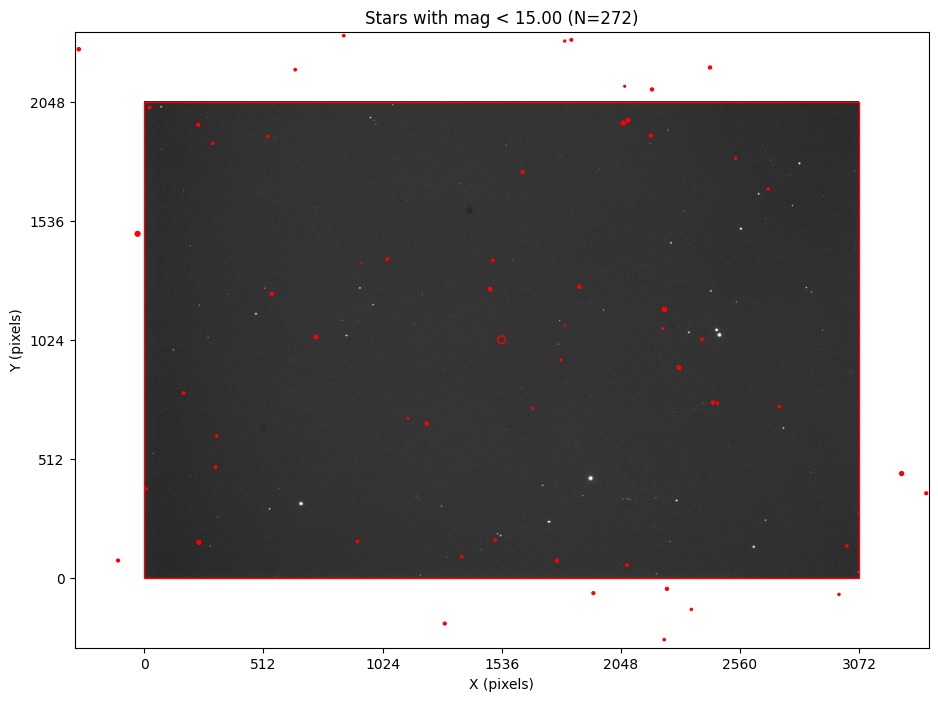

In [ ]:


fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot() 

# 6: Plot image 
src.plot_fits(ax, file)

# 7: Plot stars on top of image 
src.plot_stars(
    ax, 
    stars, 
    camera_width_pix, 
    camera_height_pix, 
    plot_lim_mag=plot_lim_mag, 
)

# 8: Add crosshair at target position 
plt.scatter(
    target["x"],
    target["y"],
    facecolors='none',
    edgecolors='red', 
    s=50, 
)
